<a href="https://colab.research.google.com/github/timlin901222/NCTU-test/blob/master/Copy_of_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Evaluating Language Technologies
This assignment must be completed in order to be considered for enrollment in the class. If you are already enrolled, failure to complete this assignment will result in your removal from the course.

## Introduction
In this assignment, we will explore different tasks core to the field of NLP. You will implement different evaluation metrics for these tasks and perform analysis of different language
technologies.

Learning objectives:
* Understand the breadth of tasks core to the field of NLP.
* Implement various evaluation methods for core NLP tasks.
* Become familiar with prompting existing LLMs via API calls.
* Identify the limitations of automatic evaluation methods.
* Practice using error analysis to identify where language technologies fail and hypothesizing why they might fail.
* Appreciate things we humans do with language that current language models cannot do.

**Notes:**
* In your solution, keep all code as-is except where it's explicitly mentioned to implement a function.
* Items marked with a star (★) should be answered in markdown text in the notebook. You will include your final notebook as a pdf with your submission.
* Results are written to the `results/` sub-directory as you go, and these are what get autograded.

**Submission:**

When you are done, run `python3 make_submission.py`. It checks that every file the
notebook should have written is present, valid, and actually filled in, then packs
them into `submission.zip` for you to upload to gradescope. Two things go in it:

* All the json files saved inside the `results/` directory. These will be autograded.
* A PDF copy of your completed notebook, titled "HW1.pdf". This is used to grade your answers to the problems marked with a (★), so check that your plots rendered before exporting.

**Setup:**
You will need to download ollama https://ollama.com and install the following models with the commands:

`ollama pull qwen3:8b`

`ollama pull llama3.2:1b`

`ollama pull llama3.2`

`ollama pull gemma3:1b`

`ollama pull gemma3:4b`

You will need about 13GB of storage to download these models. Make sure the ollama binary is in /usr/local/bin/ or you know where it is, so you can call it on the command line.

## Running on Google Colab

Set **Runtime → Change runtime type → GPU**, then run the cell below once. It
clones the repo, installs everything, points your inference cache at Drive so a
disconnect can't throw away work, and starts ollama.

Running on your own machine instead? The cell does nothing — follow the README.

In [1]:
# Colab setup. On a local machine this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    import os, subprocess, time

    STUDENT_REPO = "https://github.com/zinengtang/cs183-fall26-a1.git"
    DRIVE_DIR = "/content/drive/MyDrive/cs183-a1"

    # 1. code and data, since opening a notebook from GitHub brings only the notebook
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", STUDENT_REPO, "/content/repo"], check=True)
    os.chdir("/content/repo")

    # 2. dependencies (ffmpeg is already on Colab). Capture rather than -q: a bare
    #    CalledProcessError tells you nothing about which package refused to install.
    installed = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"],
                               capture_output=True, text=True)
    if installed.returncode != 0:
        print(installed.stdout[-2000:])
        print(installed.stderr[-2000:])
        raise RuntimeError("pip install failed -- see the output above for which package and why")

    # 3. keep generations and results on Drive -- the runtime's own disk does not
    #    survive a disconnect, and re-running inference costs far more than this does
    from google.colab import drive
    drive.mount("/content/drive")
    for sub in ("inference_cache", "results"):
        os.makedirs(f"{DRIVE_DIR}/{sub}", exist_ok=True)
        subprocess.run(["rm", "-rf", sub], check=True)
        os.symlink(f"{DRIVE_DIR}/{sub}", sub)

    # 4. ollama. Colab has no systemd, so the installer cannot start the server for us.
    #    Only the four small models are pulled here. The 5.2GB judge model that Part 4
    #    needs is pulled at Part 4, so Parts 1-3 are not stuck behind that download.
    #    The installer unpacks a .tar.zst and exits with an error if zstd is missing,
    #    which it is on Colab. There is no .tgz build to fall back to any more.
    if subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"]).returncode != 0:
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"], check=True)

    installer = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
                               shell=True, capture_output=True, text=True)
    if installer.returncode != 0:
        print(installer.stdout[-2000:])
        print(installer.stderr[-2000:])
        raise RuntimeError("the ollama installer failed, see the output above for why")

    subprocess.Popen(["ollama", "serve"])
    time.sleep(5)
    for model in ["llama3.2:1b", "llama3.2", "gemma3:1b", "gemma3:4b"]:
        print(f"pulling {model}")
        subprocess.run(["ollama", "pull", model], check=True)

    print("\nReady. Run the rest of the notebook from the top.")
else:
    print("Not on Colab -- see the README for local setup.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pulling llama3.2:1b
pulling llama3.2
pulling gemma3:1b
pulling gemma3:4b

Ready. Run the rest of the notebook from the top.


## Part 0: Setup

In [2]:
import pandas as pd
from pandas.core.frame import DataFrame
import aiohttp
import asyncio
import json
from tqdm import tqdm
from typing import Dict
import os

# ollama serves requests from a small queue, so firing hundreds at once just builds a
# backlog that runs past aiohttp's 5 minute default timeout. Bound both explicitly.
MAX_CONCURRENT_REQUESTS = 8
REQUEST_TIMEOUT_SECONDS = 600


class OllamaError(RuntimeError):
    pass


def save_results(results, filename):
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)

async def run_inference(model_name, prompt, temperature=0.0, max_tokens=16, session=None):
    """
    curl http://localhost:11434/api/generate -d '{
		"model": "llama3.2",
		"prompt":"Why is the sky blue?",
		"stream": false,
	}'
    """
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        # Reasoning models spend their whole token budget thinking before they answer,
        # which for a 16-token judge call means an empty response. Models without a
        # thinking mode ignore this.
        "think": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
        },
    }

    async def _post(open_session):
        async with open_session.post("http://localhost:11434/api/generate", json=payload) as response:
            if response.status != 200:
                # e.g. a model that has not been pulled yet answers 404 with an error
                # payload, whose .get("response", "") is an empty string -- silently
                # caching those looks exactly like a model that scores zero.
                raise OllamaError(f"ollama returned {response.status}: {(await response.text())[:200]}")
            result = await response.json()
            if "error" in result:
                raise OllamaError(result["error"])
            return result.get("response", "")

    if session is not None:
        return await _post(session)
    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as new_session:
        return await _post(new_session)

async def run_batch_inference(model_name, prompts, temperature=0.0, max_tokens=16):
    progress = tqdm(total=len(prompts))
    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    failures = []

    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as session:
        async def _run_inference(prompt):
            async with semaphore:
                try:
                    result = await run_inference(model_name, prompt, temperature, max_tokens, session=session)
                except Exception as e:
                    # returning None instead of raising keeps one bad request from
                    # discarding every other result in the batch
                    failures.append(f"{type(e).__name__}: {e}")
                    result = None
                progress.update(1)
                return result
        results = await asyncio.gather(*[_run_inference(prompt) for prompt in prompts])

    if failures:
        print(f"{len(failures)}/{len(prompts)} requests to {model_name} failed and were not cached; "
              f"re-run this cell to retry them. First failure: {failures[0]}")
    return results

def cache_inferences(model_name, exp_name, prompts, inferences):
    # skip failed requests so they are retried rather than cached as missing answers
    fresh = {prompt: inference for prompt, inference in zip(prompts, inferences) if inference is not None}
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            cache.update(fresh)
    else:
        cache = fresh
    with open(f"inference_cache/{model_name}_{exp_name}.json", "w") as f:
        json.dump(cache, f)

def load_inferences(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [cache[prompt] if prompt in cache else None for prompt in prompts]
    return [None for _ in prompts]

def get_remaining_prompts(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [prompt for prompt in prompts if prompt not in cache]
    return prompts

models = [
    "llama3.2:1b" ,
    "llama3.2",
    "gemma3:1b",
    "gemma3:4b",
]

## Part 1: Text classification (25 points)
Here, we will evaluate different LLMs on their ability to perform newsgroup classification. You will implement four standard metrics for evaluating a classifier and create a visualization of the errors using a confusion matrix. We will be using a classic NLP dataset, 20 Newsgroups (http://qwone.com/~jason/20Newsgroups/).

### Part 1.0: Setup
Load the data we will be using for evaluation. This is the development set of the dataset, so it's ok for us to do analysis with it.

We will load the possible labels from the training set, rather than the development set. If a new label has to be predicted at test-time, we wouldn't have learned it from training only on the training set!

In [3]:
classification_inputs = pd.read_csv('A1_Data/dev_data.csv')
classification_labels = pd.read_csv('A1_Data/dev_labels.csv')
classification_data = pd.merge(classification_inputs, classification_labels, on="id", how="inner")[:200]

print(f"Loaded newsgroup data of shape {classification_data.shape} with columns {classification_data.columns.tolist()}.")

labels = pd.read_csv('A1_Data/train_labels.csv')["newsgroup"].unique()
label_list = ", ".join(sorted(list(labels)))

print(f"Found {len(labels)} possible target labels: ")
print(label_list)


def normalize_prediction(text):
	"""Clean a raw model response up so it can be compared against a label.

	Model output is not guaranteed to be exactly one of the newsgroup names.
	Responses here routinely carry a trailing newline, and a model that ignores
	the "no other text" instruction may wrap the label in something longer.
	Deciding how to read a model's answer is part of the evaluation, not a
	detail -- for one of these models, skipping this step more than halves its
	measured accuracy.
	"""
	if text is None:
		# the request failed and was not cached -- re-run the inference cell to retry it
		return ""
	return text.strip()

Loaded newsgroup data of shape (200, 3) with columns ['id', 'text', 'newsgroup'].
Found 20 possible target labels: 
alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc


Now let's run inference with the different classifiers. It will take some time to run inference.

If you cannot get ollama running, `inference_cache_reference/` holds our own generations for Parts 1, 3 and 4.0 — copy them into `inference_cache/` and the cells below will use those. Say so in your writeup if you do, and note that Part 4's judge is not cached, so 4.1, 4.2 and 4.4 need a working ollama regardless.

In [4]:
def get_newsgroup_prompt(text):
	newsgroup_prompt = "In which of the following newsgroups is the following email most likely to appear? Output only the newsgroup name, no other text."
	newsgroup_prompt += f"\n\nNewsgroups:\n{label_list}\n\nEmail:\n{text}"
	return newsgroup_prompt

prompts = [get_newsgroup_prompt(text) for text in classification_data["text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt1_0_classification_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=16)
	cache_inferences(model, "pt1_0_classification_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt1_0_classification_data", prompts)
	classification_data[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


### Part 1.1: Confusion Matrix (5 points)
Complete the following functions. The first one should computes a confusion matrix for a set of predictions, and the second one should use your favorite tool (e.g. Matplotlib) to visualize it as a heatmap.

We're implementing the confusion matrix first because you might find it useful when completing the rest of Part 1.

If the model messes up the output format (e.g. outputs something that isn't one of the labels), the prediction should not be included in the matrix counts.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def part1_1_cm(x: DataFrame, y: str) -> Dict[str, Dict[str, int]]:
    cm = {true_label: {pred_label: 0 for pred_label in labels} for true_label in labels}
    for true_label, raw_pred in zip(x["newsgroup"], x[f"predictions_{y}"]):
        pred = normalize_prediction(raw_pred)
        if pred in cm[true_label]:
            cm[true_label][pred] += 1
    return cm

def part_1_1_vis(x: Dict[str, Dict[str, int]], title: str = None):
    sorted_labels = sorted(x.keys())
    matrix = np.array([[x[true][pred] for pred in sorted_labels] for true in sorted_labels])

    fig, ax = plt.subplots(figsize=(9, 9))
    im = ax.imshow(matrix, cmap="Blues")

    ax.set_xticks(range(len(sorted_labels)))
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_xticklabels(sorted_labels, rotation=90)
    ax.set_yticklabels(sorted_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    if title:
        ax.set_title(title)

    fig.colorbar(im, ax=ax, label="Count")
    plt.tight_layout()
    plt.show()

Now we'll use these functions to compute and visualize confusion matrices for each classifier.

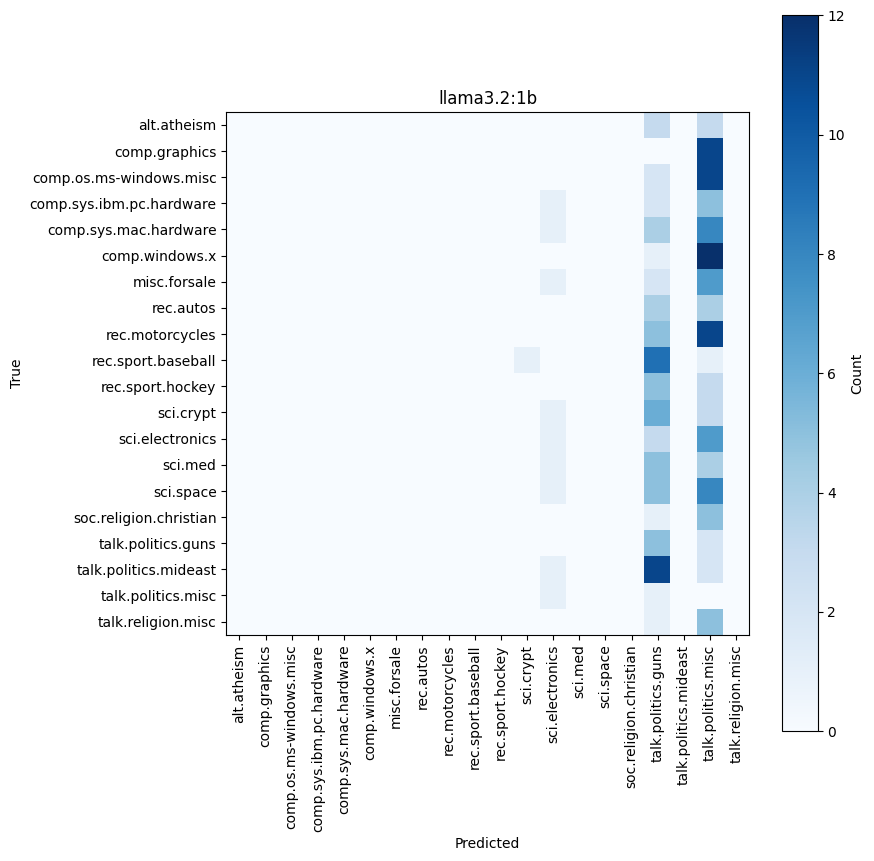

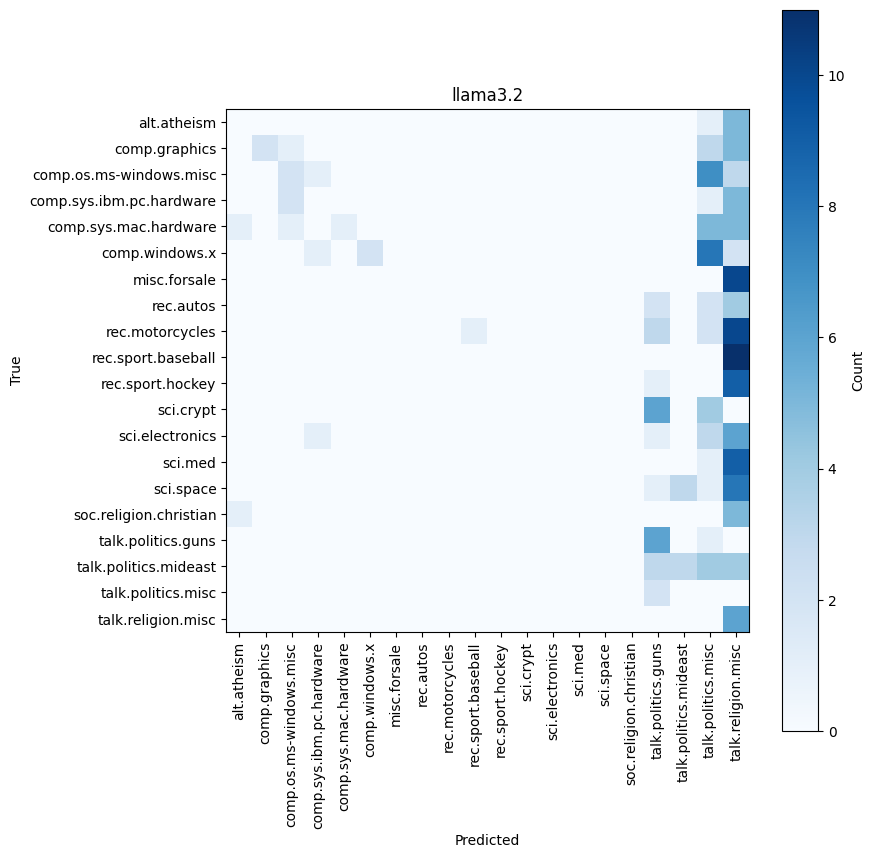

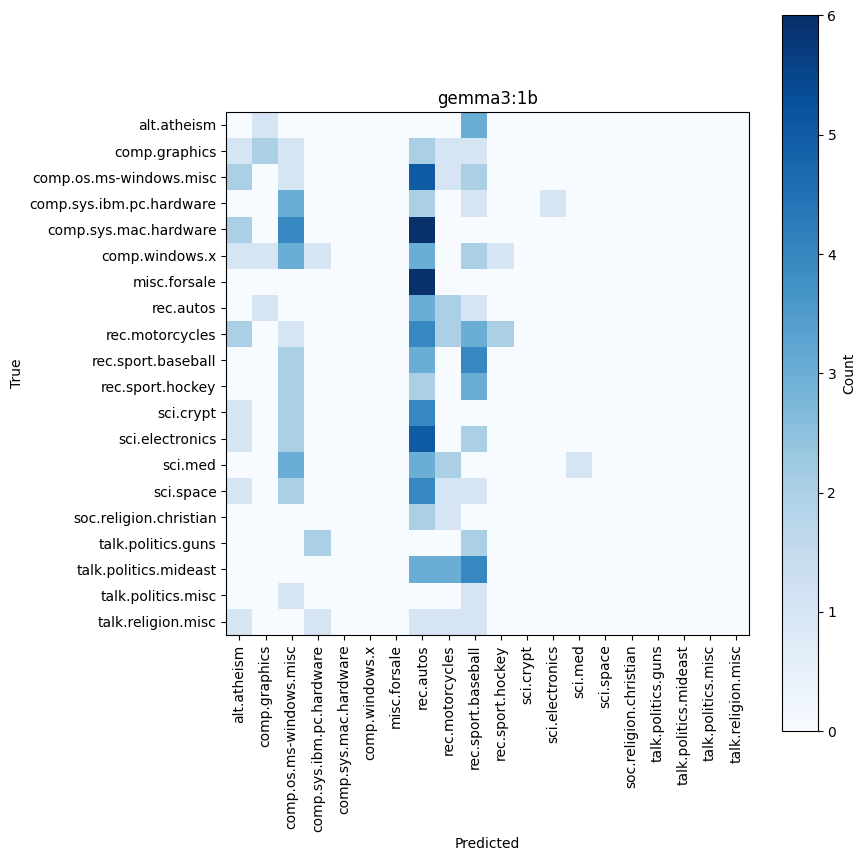

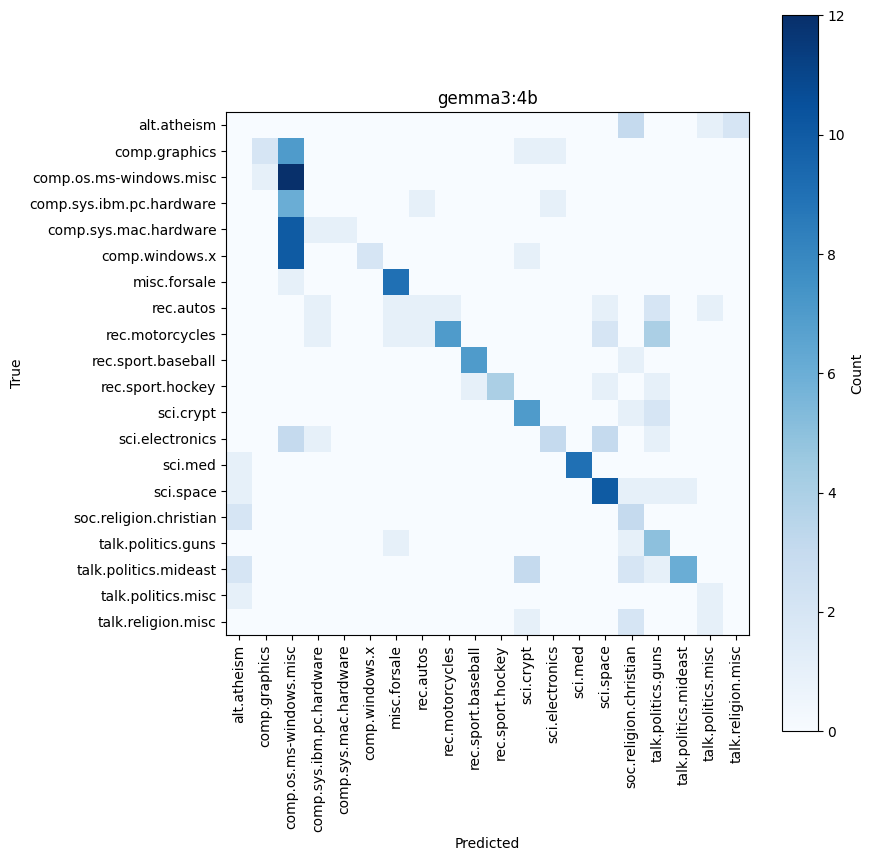

In [6]:
confusion_matrices = dict()

for model in models:
    confusion_matrices[model] = part1_1_cm(classification_data, model)
    part_1_1_vis(confusion_matrices[model], model)

In [7]:
#Check most confused pair per model
for model in models:
    cm = confusion_matrices[model]
    count, true, pred = max(
        ((cm[t][p], t, p) for t in cm for p in cm[t] if t != p),
        key=lambda triple: triple[0]
    )
    print(f"{model}: true={true!r} misclassified as {pred!r} — {count} times")

llama3.2:1b: true='comp.windows.x' misclassified as 'talk.politics.misc' — 12 times
llama3.2: true='rec.sport.baseball' misclassified as 'talk.religion.misc' — 11 times
gemma3:1b: true='comp.sys.mac.hardware' misclassified as 'rec.autos' — 6 times
gemma3:4b: true='comp.sys.mac.hardware' misclassified as 'comp.os.ms-windows.misc' — 10 times


★ Make sure the images are rendered in the notebook pdf you submit.
A: Done
★ For each of the different classifiers, which pair of classes is most often confused?

A: llama3.2:1b: true='comp.windows.x' misclassified as 'talk.politics.misc' — 12 times
llama3.2: true='rec.motorcycles' misclassified as 'talk.religion.misc' — 11 times
gemma3:1b: true='comp.sys.mac.hardware' misclassified as 'rec.autos' — 6 times
gemma3:4b: true='comp.sys.mac.hardware' misclassified as 'comp.os.ms-windows.misc' — 11 times

★ Use the scratch space below to explore the documents that are misclassified most often with these class pairings, and include snippets of a few examples below.
A: Done

★ Why might these pairs of classes be more difficult for the classifiers to distinguish?

Gemma 3.4 onfusing mac.hardware and windows.misc makes sense becasue a lot of the technical jargon is quite similar between mac and windows.

The other models seems to do a pretty poor job overall classifying the text, as seem in the confusion matrix above.



In [8]:
most_confused = {
    "llama3.2:1b": ("comp.windows.x", "talk.politics.misc"),
    "llama3.2": ("rec.motorcycles", "talk.religion.misc"),
    "gemma3:1b": ("comp.sys.mac.hardware", "rec.autos"),
    "gemma3:4b": ("comp.sys.mac.hardware", "comp.os.ms-windows.misc"),
}

for model, (true_label, pred_label) in most_confused.items():
    mask = (classification_data["newsgroup"] == true_label) & (
        classification_data[f"predictions_{model}"].apply(normalize_prediction) == pred_label
    )
    examples = classification_data[mask]
    print(f"\n===== {model}: true={true_label!r} predicted={pred_label!r} ({len(examples)} examples) =====")
    for text in examples["text"].head(2):
        print("---")
        print(text[:300])


===== llama3.2:1b: true='comp.windows.x' predicted='talk.politics.misc' (12 examples) =====
---
From: tim@kimba.catt.citri.edu.au (Tim Liddelow)
Subject: Installing MIT X11R5 on Apollo
Organization: CATT Centre at CITRI, Melbourne, Australia
Lines: 14

Can any Apollo GURUS out there let me know of their experiences building MIT X11R5,
with or without GCC 2.3.3.  In particular, is there anythin
---
From: dnh@mfltd.co.uk (Des Herriott)
Subject: XDM/xsession woes
Keywords: xdm, xterm
Lines: 22
Reply-To: dnh@mfltd.co.uk
Organization: Micro Focus Ltd.
X-Newsreader: mxrn 6.18-3


I've just managed to get xdm running from an NCR 3000 (an SVR4 486 box
running XFree86 1.2) to my NCD XDisplay.  It's pr

===== llama3.2: true='rec.motorcycles' predicted='talk.religion.misc' (10 examples) =====
---
From: oconnor@eng.umd.edu (Mark O'Connor)
Subject: Re: Question about helmets
Organization: University of Maryland, College Park, MD
Lines: 10
Distribution: world
NNTP-Posting-Host: coffee.eng.umd.edu
O

### Part 1.2: Accuracy (5 points)
Complete the following function, then use it to compute and compare the accuracies of each classifier.

Model predictions are raw text, not clean labels. Pass each one through
`normalize_prediction` (defined in Part 1.0) before comparing it to the ground
truth, and do it consistently across Parts 1.1 through 1.5 -- comparing the raw
strings scores at least one of these models far below its real accuracy.

A prediction that is still not one of the labels after normalising counts as
incorrect in Parts 1.2 through 1.5. Part 1.1 is the exception: a confusion
matrix has no cell to put it in, so it is left out of the counts there.

★ Generate a table comparing the accuracy of each of the classifier systems.
A: done, look at the cells below

★ Which one has the highest accuracy?
A: gemma3:4b

In [9]:
def part1_2_acc(x: DataFrame, y: str) -> float:
    correct = sum(
        normalize_prediction(raw_pred) == true_label
        for true_label, raw_pred in zip(x["newsgroup"], x[f"predictions_{y}"])
    )
    return correct / len(x)

accuracies: dict[str, float] = dict()

for model in models:
    accuracies[model] = part1_2_acc(classification_data, model)

save_results(accuracies, "results/accuracies.json")

best_model = max(accuracies, key=accuracies.get)

In [10]:
print(best_model)

gemma3:4b


In [11]:
accuracy_table = (
    pd.DataFrame(accuracies.items(), columns=["model", "accuracy"])
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)
accuracy_table

,model,accuracy
0,gemma3:4b,0.445
1,llama3.2,0.110
2,gemma3:1b,0.065
3,llama3.2:1b,0.030


### Part 1.3: Precision (5 points)
Complete the following function that returns, for each class, the precision of the classifier's labels given ground-truth labels. (note: if there are no predictions for a given class, then precision should be 0)

★ Generate a table showing, for the best-performing classifier, the precision of its labels across each class.
A: see cells below

★ For which class are its labels the most accurate? The least?
A: Highest precision: 'sci.med' (1.000)
Lowest precision: 'comp.sys.ibm.pc.hardware' (0.000)

In [12]:
def part1_3_prec(x: DataFrame, y: str) -> dict[str, float]:
    preds = x[f"predictions_{y}"].apply(normalize_prediction)
    precision = {}
    for c in labels:
        predicted_as_c = preds == c
        denom = predicted_as_c.sum()
        if denom == 0:
            precision[c] = 0.0
        else:
            correct = (predicted_as_c & (x["newsgroup"] == c)).sum()
            precision[c] = float(correct) / float(denom)
    return precision

if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_prec = None
else:
    best_model_prec = part1_3_prec(classification_data, best_model)

save_results(best_model_prec, "results/best_model_prec.json")

prec_table = (
    pd.DataFrame(best_model_prec.items(), columns=["class", "precision"])
    .sort_values("precision", ascending=False)
    .reset_index(drop=True)
)
prec_table

best_class = max(best_model_prec, key=best_model_prec.get)
worst_class = min(best_model_prec, key=best_model_prec.get)
print(f"Highest precision: {best_class!r} ({best_model_prec[best_class]:.3f})")
print(f"Lowest precision: {worst_class!r} ({best_model_prec[worst_class]:.3f})")

Highest precision: 'sci.med' (1.000)
Lowest precision: 'comp.sys.ibm.pc.hardware' (0.000)


In [13]:
prec_table = (
    pd.DataFrame(best_model_prec.items(), columns=["class", "precision"])
    .sort_values("precision", ascending=False)
    .reset_index(drop=True)
)
prec_table

,class,precision
0,sci.med,1.000000
1,comp.windows.x,1.000000
2,rec.sport.hockey,1.000000
3,comp.sys.mac.hardware,1.000000
4,rec.motorcycles,0.875000
5,rec.sport.baseball,0.875000
6,talk.politics.mideast,0.857143
7,misc.forsale,0.750000
8,comp.graphics,0.666667
9,sci.electronics,0.600000


### Part 1.4: Recall (5 points)
Complete the following function that returns, for each target class, the recall of the classifier's labels. (note: if there are no ground truth labels for a given class, the recall should be 0)

★ Generate a table showing, for each target class, the recall of the best-performing model's labels across each class.

★ For which class is recall the highest? The lowest?

> **Answer:** Done, check cell below.

> **Answer:** Recall is highest for `comp.os.ms-windows.misc` (0.923) and lowest for `comp.sys.ibm.pc.hardware` (0.000) -- the model never correctly recovers a true `comp.sys.ibm.pc.hardware` example.

In [14]:
def part1_4_rec(x: DataFrame, y: str) -> dict[str, float]:
    # TODO: Implement this function
    preds = x[f"predictions_{y}"].apply(normalize_prediction)
    recall = {}
    for c in labels:
        true_as_c = x["newsgroup"] == c
        denom = true_as_c.sum()
        if denom == 0:
            recall[c] = 0.0
        else:
            correct = (true_as_c & (preds == c)).sum()
            recall[c] = float(correct) / float(denom)
    return recall

if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_rec = None
else:
    best_model_rec = part1_4_rec(classification_data, best_model)

save_results(best_model_rec, "results/best_model_rec.json")

print(best_model_rec)

{'sci.med': 0.9, 'rec.autos': 0.125, 'rec.motorcycles': 0.4375, 'sci.electronics': 0.2727272727272727, 'talk.politics.mideast': 0.42857142857142855, 'comp.sys.ibm.pc.hardware': 0.0, 'comp.os.ms-windows.misc': 0.9230769230769231, 'talk.politics.misc': 0.5, 'comp.sys.mac.hardware': 0.07692307692307693, 'rec.sport.baseball': 0.6363636363636364, 'sci.crypt': 0.7, 'sci.space': 0.7142857142857143, 'comp.graphics': 0.18181818181818182, 'alt.atheism': 0.0, 'soc.religion.christian': 0.5, 'rec.sport.hockey': 0.36363636363636365, 'comp.windows.x': 0.15384615384615385, 'talk.religion.misc': 0.0, 'talk.politics.guns': 0.7142857142857143, 'misc.forsale': 0.9}


In [15]:
best_class = max(best_model_rec, key=best_model_rec.get)
worst_class = min(best_model_rec, key=best_model_rec.get)
print(f"Highest recall: {best_class!r} ({best_model_rec[best_class]:.3f})")
print(f"Lowest recall: {worst_class!r} ({best_model_rec[worst_class]:.3f})")

Highest recall: 'comp.os.ms-windows.misc' (0.923)
Lowest recall: 'comp.sys.ibm.pc.hardware' (0.000)


In [16]:
rec_table = (
    pd.DataFrame(best_model_rec.items(), columns=["class", "recall"])
    .sort_values("recall", ascending=False)
    .reset_index(drop=True)
)
rec_table

,class,recall
0,comp.os.ms-windows.misc,0.923077
1,sci.med,0.900000
2,misc.forsale,0.900000
3,talk.politics.guns,0.714286
4,sci.space,0.714286
5,sci.crypt,0.700000
6,rec.sport.baseball,0.636364
7,talk.politics.misc,0.500000
8,soc.religion.christian,0.500000
9,rec.motorcycles,0.437500


### Part 1.5: F1 (5 points)

A weighted average F1 score computes an average F1 score over all target classes, weighted by the true number of instances of that class:

![test](https://github.com/zinengtang/cs183-fall26-a1/blob/main/A1_Data/f1.png?raw=1)

Here, *f* is a classification function, *C* is the set of classes, *D* is the set of evaluation data with ground-truth labels, and *D_c* is the set of data whose ground-truth label is *c*.

Implement two functions below:
* A function that returns, for a target class, the F1 of a classifier's labels given ground truth labels
* A function that uses the previous function to compute a weighted average F1 score

In [17]:
def part1_5_class_f1(x: DataFrame, y: str, z: str) -> float:
    preds = x[f"predictions_{y}"].apply(normalize_prediction)
    predicted_as_z = preds == z
    true_as_z = x["newsgroup"] == z
    correct = (predicted_as_z & true_as_z).sum()
    pred_count = predicted_as_z.sum()
    true_count = true_as_z.sum()
    precision = float(correct) / float(pred_count) if pred_count > 0 else 0.0
    recall = float(correct) / float(true_count) if true_count > 0 else 0.0
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)
def part1_5_weighted_f1(x: DataFrame, y: str) -> float:
    total = len(x)
    return sum(
        (x["newsgroup"] == c).sum() / total * part1_5_class_f1(x, y, c)
        for c in labels
    )

★ Generate a table comparing the weighted F1 score of each classifier.

★ Which is the best classifier according to weighted F1? How and why might this differ from an accuracy comparison (Part 1.2)?

> **Answer:** Done, check cell below.

> **Answer:** `gemma3:4b` is best by weighted F1 (0.441) -- far ahead of `llama3.2` (0.096), `gemma3:1b` (0.050), and `llama3.2:1b` (0.010). This gap is much larger than the one seen in the accuracy comparison. Weighted F1 requires a model to have both good precision and good recall on every class, while accuracy only counts total correct/total. The three weaker models default to a narrow set of "go-to" predictions regardless of input (visible as vertical stripes in their confusion matrices), which can still yield passable accuracy if the default label happens to be common -- but it tanks recall on every other class to near zero, collapsing their per-class F1 scores and dragging the weighted average far below what accuracy alone suggested.

In [18]:
f1s: dict[str, float] = dict()

for model in models:
    f1s[model] = part1_5_weighted_f1(classification_data, model)

save_results(f1s, "results/f1s.json")

f1_table = pd.DataFrame(f1s.items(), columns=["model", "weighted_f1"]).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
print(f1_table)
best_f1_model = max(f1s, key=f1s.get)
print(f"Best by weighted F1: {best_f1_model!r} ({f1s[best_f1_model]:.3f})")

         model  weighted_f1
0    gemma3:4b     0.442709
1     llama3.2     0.094537
2    gemma3:1b     0.050870
3  llama3.2:1b     0.009768
Best by weighted F1: 'gemma3:4b' (0.443)


## Part 2: Automatic speech recognition (25 points)
Here, we'll explore using a popular open-source automatic speech recognition system to compare its performance across English speakers whose native language differs.

### Part 2.0: Setup
`transcriptions.tsv` ships with the repo, so the cell below only downloads the Speech Accent Archive (https://www.kaggle.com/datasets/rtatman/speech-accent-archive/data) -- an 865MB archive that takes a while to extract -- when those transcripts are missing or incomplete.

In [19]:
import os

# transcriptions.tsv ships with the repo. The 865MB audio archive is only needed
# when it is missing or short, so decide that first and skip the download otherwise.
transcript_counts = {}
if os.path.exists('transcriptions.tsv'):
    with open('transcriptions.tsv') as infile:
        for line in infile:
            language, _, _ = line.rstrip("\n").partition("\t")
            transcript_counts[language] = transcript_counts.get(language, 0) + 1

need_to_transcribe = not transcript_counts or any(n != 20 for n in transcript_counts.values())

if need_to_transcribe:
    import kagglehub
    speech_accent_path = kagglehub.dataset_download("rtatman/speech-accent-archive")
    speakers = pd.read_csv(f"{speech_accent_path}/speakers_all.csv")
    language_counts = speakers['native_language'].value_counts()
    languages_with_over_20_samples = set(language_counts[language_counts >= 20].index)
else:
    languages_with_over_20_samples = set(transcript_counts)

print(f"{len(languages_with_over_20_samples)} languages with at least 20 samples:")
print(sorted(languages_with_over_20_samples))

21 languages with at least 20 samples:
['amharic', 'arabic', 'cantonese', 'dutch', 'english', 'farsi', 'french', 'german', 'italian', 'japanese', 'korean', 'macedonian', 'mandarin', 'polish', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish', 'turkish', 'vietnamese']


If the transcripts do need regenerating, load WhisperX. This might take some time to load.

In [20]:
if need_to_transcribe:
    import whisperx

    # Needs whisperx >= 3.8: 3.4.2 could not load its own VAD against current
    # pyannote-audio, and it also caps out at Python 3.12, which Colab is past.
    whisperx_model = whisperx.load_model("tiny", "cpu", compute_type="float32", language="en")

Now let's run inference. This is the smallest model we could run inference on, so its performance isn't going to be great. But, it shouldn't take *too* long to run on your local machine!

In [21]:
from tqdm import tqdm

transcriptions = {language: list() for language in languages_with_over_20_samples}

if need_to_transcribe:
    recordings_filepath = f"{speech_accent_path}/recordings/recordings/"
    for language in languages_with_over_20_samples:
        print(f"Transcribing for native language {language}...")
        for i in tqdm(range(20)):
            filename = f"{language}{i + 1}.mp3"
            audio = whisperx.load_audio(f"{recordings_filepath}/{filename}")
            transcription = whisperx_model.transcribe(audio, language="en")
            # flatten to text here, so this path and the tsv path agree on the type
            text = " ".join(segment["text"] for segment in transcription["segments"])
            transcriptions[language].append(" ".join(text.split()))

    with open("transcriptions.tsv", "w") as ofile:
        for language, transcripts in transcriptions.items():
            for transcript in transcripts:
                ofile.write(f"{language}\t{transcript}\n")
else:
    with open('transcriptions.tsv') as infile:
        for line in infile:
            # partition rather than split so an empty transcript is still a valid row
            language, _, transcript = line.rstrip("\n").partition("\t")
            if language in transcriptions:
                transcriptions[language].append(transcript)

### Part 2.1: Word error rate (10 points)
Implement the following function to compute the word error rate of a candidate transcription against a reference. It takes the **reference** first and the candidate second, matching the call below. Each of the recordings we transcribed are readings of the same English text: *"Please call Stella.  Ask her to bring these things with her from the store:  Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids.  She can scoop these things into three red bags, and we will go meet her Wednesday at the train station."*

Compare the two token lists case-insensitively. Whether a transcript writes
*Please* or *please* is a choice the ASR system made about how to render the
words it heard, not a recognition error, so folding case keeps the metric
measuring what it is supposed to measure.

In [22]:
def part2_1(x: list[str], y: list[str]) -> float:
    ref = [w.lower() for w in x]
    cand = [w.lower() for w in y]
    n, m = len(ref), len(cand)

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref[i - 1] == cand[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(
                    dp[i - 1][j],       # deletion
                    dp[i][j - 1],       # insertion
                    dp[i - 1][j - 1],   # substitution
                )

    return dp[n][m] / n

Then let's evaluate for all of the candidate transcriptions and each of the native languages.

★ Generate a table comparing the average WER across each of the languages.

In [23]:
import nltk
nltk.download('punkt_tab')

reference = "Please call Stella.  Ask her to bring these things with her from the store: " \
            "Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack " \
            "for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids. " \
            "She can scoop these things into three red bags, and we will go meet her Wednesday at the "\
            "train station."

language_wers = {language: list() for language in languages_with_over_20_samples}
for language, transcripts in transcriptions.items():
    for candidate in transcripts:
        language_wers[language].append(part2_1(nltk.word_tokenize(reference), nltk.word_tokenize(candidate)))

save_results(language_wers, "results/language_wers.json")

# TODO: Scratch space for computing average WER and generating a table to compare across native languages.

avg_wers = {language: sum(wers) / len(wers) for language, wers in language_wers.items()}

wer_table = (
    pd.DataFrame(avg_wers.items(), columns=["language", "avg_wer"])
    .sort_values("avg_wer")
    .reset_index(drop=True)
)
print(wer_table)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


      language   avg_wer
0       german  0.083766
1      english  0.085714
2   macedonian  0.092857
3      swedish  0.101299
4     romanian  0.109091
5        dutch  0.114286
6        farsi  0.114286
7       polish  0.131169
8     japanese  0.133117
9       french  0.140260
10      arabic  0.141558
11     italian  0.151948
12  portuguese  0.160390
13     russian  0.161039
14    mandarin  0.166883
15      korean  0.172727
16   cantonese  0.175325
17     turkish  0.186364
18     spanish  0.221429
19     amharic  0.227273
20  vietnamese  0.266234


### Part 2.2: Confidence intervals (10 points)

Each average WER you just computed comes from 20 recordings. Twenty *different*
speakers of the same native language would have given you a different average.
Before ranking the languages, you need to know how much that number moves.

You cannot collect more recordings, but you can estimate the spread from the
sample you already have. Draw 20 values *with replacement* from a language's 20
WERs and average them; that is one plausible alternative sample. Repeat it many
times and the middle 95% of those averages is a 95% confidence interval for the
mean.

Implement the function below. `x` is the list of WER values for one language and
`y` is how many times to resample; return the lower and upper bounds of the 95%
interval.

In [24]:
import random
def part2_2_ci(x: list[float], y: int = 10000) -> tuple[float, float]:
    n = len(x)
    boot_means = [sum(random.choices(x, k=n)) / n for _ in range(y)]
    boot_means.sort()
    lower = boot_means[int(0.025 * y)]
    upper = boot_means[int(0.975 * y)]
    return (lower, upper)

language_wer_cis = dict()
for language, wers in language_wers.items():
    language_wer_cis[language] = part2_2_ci(wers)

save_results(language_wer_cis, "results/language_wer_cis.json")

# TODO: Scratch space for adding the intervals to your Part 2.1 table.

wer_ci_table = pd.DataFrame([
    {
        "language": language,
        "avg_wer": avg_wers[language],
        "ci_low": language_wer_cis[language][0],
        "ci_high": language_wer_cis[language][1],
    }
    for language in avg_wers
]).sort_values("avg_wer").reset_index(drop=True)

print(wer_ci_table)

      language   avg_wer    ci_low   ci_high
0       german  0.083766  0.067532  0.101948
1      english  0.085714  0.062987  0.111039
2   macedonian  0.092857  0.072078  0.117532
3      swedish  0.101299  0.075325  0.136364
4     romanian  0.109091  0.088961  0.131818
5        dutch  0.114286  0.091558  0.137662
6        farsi  0.114286  0.085714  0.148052
7       polish  0.131169  0.096753  0.168831
8     japanese  0.133117  0.102597  0.166234
9       french  0.140260  0.108442  0.172727
10      arabic  0.141558  0.118182  0.166883
11     italian  0.151948  0.119481  0.188961
12  portuguese  0.160390  0.104545  0.238961
13     russian  0.161039  0.120779  0.207143
14    mandarin  0.166883  0.134416  0.201299
15      korean  0.172727  0.131169  0.217532
16   cantonese  0.175325  0.129870  0.225325
17     turkish  0.186364  0.125974  0.264286
18     spanish  0.221429  0.168182  0.282468
19     amharic  0.227273  0.174675  0.285065
20  vietnamese  0.266234  0.200649  0.340260


★ Extend your table from Part 2.1 with each language's confidence interval.

★ You named the lowest-WER languages in Part 2.1. Taking the intervals into
account, which of those are actually distinguishable from one another, and which
are not?

★ Some pairs of languages *are* clearly separated. What is different about those
pairs, compared to the ones you cannot separate?

★ What would you need in order to separate the languages whose intervals
currently overlap?

> **Answer:** Done, check cell above.

> **Answer:** The lowest-WER languages from Part 2.1 -- `german` (8.4%), `english` (8.6%), `macedonian` (9.3%), `swedish` (10.1%), `romanian` (10.9%), `dutch`/`farsi` (11.4%), and `polish` (13.1%) -- all have heavily overlapping 95% CIs (e.g. German's `[6.8%, 10.2%]` overlaps Polish's `[9.6%, 16.8%]`). With only 20 recordings per language, we can't confidently rank any of them against each other, they're statistically indistinguishable as a cluster. What *is* distinguishable is that whole low-WER cluster versus languages further down the list: German's CI `[6.8%, 10.2%]` doesn't overlap Italian's `[11.9%, 18.8%]`, Russian's `[12.1%, 20.6%]`, or Vietnamese's `[19.9%, 33.9%]` at all, so we can say confidently that this low-WER group genuinely outperforms the higher-WER languages, even without being able to rank within the group itself.

> **Answer:** Clearly separated pairs (e.g. `german` vs. `vietnamese`) have a gap between their point estimates that dwarfs both intervals' widths: German's average (8.4%) sits nowhere close to Vietnamese's range even at German's worst-case upper bound. Overlapping pairs, by contrast, are usually adjacent in the ranking and/or have wide intervals driven by high variance across their 20 speakers -- e.g. `portuguese` spans `[10.5%, 23.9%]`, a 13-point range wide enough to swallow several neighboring languages' entire intervals. So separation comes from a large true difference in average WER, tight (low-variance) intervals, or both -- and the overlapping middle of the table lacks both.

> **Answer:** More recordings per language: a larger sample size, not more bootstrap resamples. The CI width reflects genuine uncertainty from having only 20 speakers; increasing `y` (the resample count) only makes the estimate of that existing uncertainty more precise, it doesn't shrink the uncertainty itself. To actually separate close languages like `german`/`english`/`macedonian`, we'd need more transcribed speakers per native language.

### Part 2.3: Error analysis (5 points)
★ Which languages have the lowest WER? Which have the highest?

★ Why might these languages have lower WER?

★ Which of the differences you just described survive the confidence intervals
from Part 2.2, and which are within the noise?

> **Answer:** Lowest WER: `german` (8.4%), `english` (8.6%), and `macedonian` (9.3%). Highest WER: `vietnamese` (26.6%), `amharic` (22.7%), and `spanish` (22.1%).

> **Answer:** This system uses WhisperX's smallest model, deliberately chosen as the weakest option available, which means it has the least capacity to generalize across accents and leans hardest on whatever it saw most during training, which is likely disproportionately English and other Western/Germanic-family languages. `german`, `english`, `macedonian`, `swedish`, and `dutch` (the low-WER cluster) are all Germanic or otherwise phonologically close to English, so their speakers' accented English tends to match the model's training distribution well. `vietnamese`, `amharic`, and `spanish`-tier languages are phonologically much more distant from English, producing accented speech the small model has less exposure to and struggles harder to transcribe.

> **Answer:** The broad contrast survives: the whole low-WER cluster's confidence intervals (e.g. `german` `[6.8%, 10.2%]`) don't overlap the high-WER cluster's intervals at all (e.g. `spanish` `[16.8%, 28.3%]`, `vietnamese` `[19.9%, 33.9%]`), so "these language groups are genuinely easier/harder for the model" is a real, statistically supported effect, not noise. What does *not* survive is the specific ranking within each cluster: `german` vs. `english` vs. `macedonian` all have overlapping confidence intervals with each other, so we can't say which of the three is truly lowest -- and likewise `vietnamese`, `amharic`, and `spanish` overlap each other at the high end, so their exact 1st/2nd/3rd-worst ordering is within the noise of only 20 recordings per language.

## Part 3: Machine translation (25 points)
In this part we will evaluate models on their abilities to translate text via BLEU score.

### Part 3.0: Setup


Prepare the dataset we will use for evaluation. These are the Czech, Chinese and Gujarati halves of the standard WMT19 into-English translation sets. We will just use the first 25 examples of each for evaluation.

In [25]:
from datasets import load_dataset
from itertools import islice

# streaming=True reads only the validation shards. Without it, load_dataset also
# materialises every training split -- 7.3M cs-en rows, 26M zh-en rows, ~13GB of
# HuggingFace cache -- to reach the 75 sentences we actually evaluate on.
hf_dataset_cs = load_dataset("wmt/wmt19", "cs-en", split="validation", streaming=True)
hf_dataset_zh = load_dataset("wmt/wmt19", "zh-en", split="validation", streaming=True)
hf_dataset_gu = load_dataset("wmt/wmt19", "gu-en", split="validation", streaming=True)

dataset_items_cs = []
for i, item in enumerate(islice(hf_dataset_cs, 25)):
    dataset_items_cs.append({
        'id': i,
        'czech_text': item['translation']['cs'],
        'english_text': item['translation']['en']
    })

dataset_items_zh = []
for i, item in enumerate(islice(hf_dataset_zh, 25)):
    dataset_items_zh.append({
        'id': i,
        'chinese_text': item['translation']['zh'],
        'english_text': item['translation']['en']
    })

dataset_items_gu = []
for i, item in enumerate(islice(hf_dataset_gu, 25)):
    dataset_items_gu.append({
        'id': i,
        'gujarati_text': item['translation']['gu'],
        'english_text': item['translation']['en']
    })

dataset_cs = pd.DataFrame(dataset_items_cs)
dataset_zh = pd.DataFrame(dataset_items_zh)
dataset_gu = pd.DataFrame(dataset_items_gu)
print(f"Loaded translation data of shape {dataset_cs.shape} with columns {dataset_cs.columns.tolist()}.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded translation data of shape (25, 3) with columns ['id', 'czech_text', 'english_text'].


We will use a simple nltk based tokenizer to encode the n-gram tokens for computing the bleu score.

In [26]:
import nltk
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    # Download required NLTK data if not already downloaded
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    # Tokenize the text into a list of tokens
    tokens = word_tokenize(text)
    return tokens


In [27]:
tokenize_text("Welcome to CS-183: we are learning about NLP evaluations today!!!")

['Welcome',
 'to',
 'CS-183',
 ':',
 'we',
 'are',
 'learning',
 'about',
 'NLP',
 'evaluations',
 'today',
 '!',
 '!',
 '!']

In [28]:
dataset_cs.head()

,id,czech_text,english_text
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi..."
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ..."


In [29]:
dataset_zh.head()

,id,chinese_text,english_text
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...


In [30]:
dataset_gu.head()

,id,gujarati_text,english_text
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...


now let's get the model predictions for these translations

In [31]:
def get_translation_prompt(text, source_language):
	translation_prompt = f"Translate the following text from {source_language} to English. Output only the translation, no other text."
	translation_prompt += f"\n\nText:\n{text}"
	return translation_prompt

prompts_cs = [get_translation_prompt(text, "Czech") for text in dataset_cs["czech_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_cs", prompts_cs)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_cs", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_cs", prompts_cs)
	dataset_cs[f"predictions_{model}"] = inferences

prompts_zh = [get_translation_prompt(text, "Chinese") for text in dataset_zh["chinese_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_zh", prompts_zh)
	print(f"Remaining prompts: {len(remaining_prompts)}")
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_zh", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_zh", prompts_zh)
	dataset_zh[f"predictions_{model}"] = inferences

prompts_gu = [get_translation_prompt(text, "Gujarati") for text in dataset_gu["gujarati_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_gu", prompts_gu)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_gu", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_gu", prompts_gu)
	dataset_gu[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


...

0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


In [32]:
dataset_cs

,id,czech_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...,Travel warning issued by the rights movement f...,Movement for Civil Rights issued a travel warn...,Committee for Civic Rights issued a travel war...,The Civil Rights Movement issued a travel warn...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...,National Association for the Advancement of Co...,National Association for the Advancement of Co...,The National Association for the Advancement o...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi...",Travel advisories of the NAACP for the state o...,The NAACP travel advisory for the state of Mis...,“NAACP travel recommendation for the state of ...,“Travel recommendations from the NAACP for the...
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...,They have taken this step based on the current...,The NAACP stated that it took this step based ...,The NAACP has stated that this step was taken ...,NAACP stated that it took this step based on t...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ...","""Something is being destroyed.""",There is a violation of civil rights.,“He is violating citizens’ rights.”,Human rights are being violated.
5,5,Lidé jsou zastavováni policisty jen kvůli barv...,They're being pulled over because of their ski...,They are harassed by police just because of th...,People are stopped by police just because of t...,People are stopped by police only because of t...,“People are being stopped by police solely bec...
6,6,„Hromadí se nám dosud největší množství stížno...,"""We are hearing complaints at a rate we haven'...","""Despite our complaints, we still have the mos...",The complaints are mounting to the greatest ex...,We have so far received the largest amount of ...,“We are still accumulating the largest amount ...
7,7,"Jedná se o první varování svého druhu, které o...",It is the first such warning that the organiza...,"It is the first warning of its species, which ...",It is the first warning of its kind that the o...,"It is the first warning of our species, issued...",This is the first warning of its kind issued b...
8,8,"Mezi incidenty, které organizace citovala, byl...",The group cited incidents such as racial slurs...,racially motivated hate speech incidents cited...,"Among the incidents cited by the organization,...","During incidents cited by the organization, ra...",Among the incidents cited by the organizations...
9,9,Sanders zemřel za sporných okolností na začátk...,Sanders died under questionable circumstances ...,He died under suspicious circumstances at the ...,He died under disputed circumstances at the be...,Sanders died under suspicious circumstances at...,Sanders died under disputed circumstances at t...


In [33]:
dataset_zh

,id,chinese_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau...","Last week, the period drama ""Beautiful Private...","Last week, the costume drama ""Beauty and the F...","Last week, the temporary suspension of the his...","Last week, the costume drama ""Beauty's Private..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...,Travel warning issued by civil rights group ag...,Human rights groups issue travel warning for M...,Civil rights groups are issuing travel warning...,Civil rights groups have issued travel warning...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...,Due to the state's discriminatory policies and...,Due to discriminatory policies and racist atta...,Due to discriminatory policies and racial atta...,Due to discriminatory policies and racial atta...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi...","""NAACP密苏里州旅行咨询于2017年8月28日生效，要求所有非裔美国人、游客以及密苏里州...","The NAACP Travel Advisory for Missouri, effect...","“On August 28, 2017, the NAACP has issued a ca...","Issued on August 28, 2017, the NAACP’s Missour..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...,The NAACP has stated that a recent Missouri la...,The NAACP stated that a recent law passed in M...,The NAACP has pointed out that a recent law in...,The NAACP pointed out that a recently passed M...
5,5,侵犯公民权利的行为正发生在人们身上。,"""You have violations of civil rights that are ...",Violations of citizen rights are happening all...,The behavior that infringes on citizens' right...,Violations of human rights are happening right...,Actions violating citizens' rights are current...
6,6,他们因肤色被停车盘问，被殴打或被杀害，”密苏里州 NAACP 主席罗德·查培尔告诉堪萨斯城星...,They're being pulled over because of their ski...,They were stopped and beaten or killed by driv...,They were beaten or killed because of their sk...,“They were questioned about their skin color a...,"“They were stopped and questioned, beaten, or ..."
7,7,“我们收到了许多投诉，数量前所未有。”,"""We are hearing complaints at a rate we haven'...","""We have received many complaints, the number ...","""We have received many complaints, a number un...","We have received many complaints, the number i...","We have received a large number of complaints,..."
8,8,这是该组织在美国针对某个州发布的第一个此类警告。,It is the first such warning that the organiza...,This is the first warning issued by the organi...,This is the first of its kind warning issued b...,This is the first such warning issued by this ...,This is the first such warning issued by the o...
9,9,该组织援引了密苏里大学对黑人学生的种族诽谤以及 28 岁田纳西州黑人男性托利·桑德斯的死亡事件。,The group cited incidents such as racial slurs...,The organization cited the racist remarks made...,The organization cited the racial slurs direct...,The organization invoked the assistance of Mis...,This organization cited the Missouri Universit...


In [34]:
dataset_gu

,id,gujarati_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...,"After beating his brother, he went to the cent...","After the barrier was broken, thousands were i...",The potatoes collapsed and thousands of them w...,"After the barrier was broken, thousands panick..."
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...,Thousands of people were trapped in fear of be...,Thousands of people were forced to take shelte...,“A central park was threatened with a deadly s...,A stampede in Central Park occurred after poli...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...,The Democratic New York State Legislature has ...,Democratic New York government's prominent fig...,Democratic New York government’s large petitio...,Democratic New York state dignitaries Andrew C...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...,Gujarati to English translation:\nAs the day e...,After the Beriyar (a type of fruit) fell on Sa...,"On Saturday evening, after encountering obstac...","On Saturday evening, after the barrier was ere..."
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...,Social justice movements have started to take ...,The phenomenon of social justice issues escala...,Social justice issues have brought about a cri...,The burning issues of social justice overshado...
5,5,"લગભગ 60,000 લોકોથી ગ્લોબલ સિટીઝન ફેસ્ટિવલ માટે...","About 60,000 people filled the park's Great La...",The main gate of the global city festival has ...,"The park became almost 60,000 people for the G...",The park has become crowded with thousands of ...,The Great Lawn of the park was packed with alm...
6,6,કેટલાક સ્પીકરોએ પ્રેક્ષકોને સુપ્રીમ કોર્ટના નો...,Some speakers asked the audience to call their...,Some members of the opposition have expressed ...,Some speakers called upon their Congress party...,Some politicians asked their congress members ...,Some speakers asked their congressional member...
7,7,"બીજી ઓક્ટોબરથી અન્ના હજારે કરશે ભૂખ હડતાળ, PM ...",Anna Hazare will go on hunger strike from 2nd ...,He will write a letter to PM Modi from Annha.,"From October, Anna Hazare will start hunger st...","Second October to half-past midnight, Prime Mi...",Anna Hazare will go on a hunger strike from Oc...
8,8,મહારાષ્ટ્ર: સામાજીક કાર્યકર્તા અન્ના હજારેએ બી...,Maharashtra: The social activist Anna Hazare h...,The social worker Annapoorna Hazare has filed ...,Maharashtra: Social activist Anna Hazare has a...,Maharashtra: The Social Workers Ananya have be...,Maharashtra: Social worker Anna Hazare has ann...
9,9,અન્ના હજારેએ વડાપ્રધાન પર પ્રહાર કરતા કહ્યું ક...,Anna Hazare has heavily criticized the Prime m...,Annaji has said that the government led by the...,Anna Hazare has said that the BJP-led governme...,"The Prime Minister was going to confront him, ...","Anna Hazare attacked the Prime Minister, sayin..."


### Part 3.1 n-gram precision (5 points)

complete the following function to calculate the n-gram precision of a predicted translation given the reference.

`pred` and `ref` are the raw translation strings, the same ones `bleu` is given in Part 3.3. Use the `tokenize_text` helper from Part 3.0 on them.

In [35]:
from collections import Counter

def ng_prec(pred, ref, n):
    pred_tokens = tokenize_text(pred)
    ref_tokens = tokenize_text(ref)

    pred_ngrams = [tuple(pred_tokens[i:i+n]) for i in range(len(pred_tokens) - n + 1)]
    ref_ngrams = [tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens) - n + 1)]

    if len(pred_ngrams) == 0:
        return 0.0

    pred_counts = Counter(pred_ngrams)
    ref_counts = Counter(ref_ngrams)

    clipped = sum(min(count, ref_counts[gram]) for gram, count in pred_counts.items())
    total = len(pred_ngrams)

    return clipped / total

In [36]:
ngram_precisions_cs = dict()
for model in models:
    ngram_precisions_cs[model] = [
        [ng_prec(prediction, reference, n) for n in (1, 2, 3, 4)]
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(ngram_precisions_cs, "results/ngram_precisions_cs.json")

### Part 3.2 brevity penalty (5 points)

complete the following function to calculate the brevity penalty for the bleu score

`pred` and `ref` are the raw strings here too.

In [37]:
import math

def brev_pen(pred, ref):
    pred_tokens = tokenize_text(pred)
    ref_tokens = tokenize_text(ref)

    c = len(pred_tokens)  # candidate length
    r = len(ref_tokens)   # reference length

    if c == 0:
        return 0.0
    if c > r:
        return 1.0
    return math.exp(1 - r / c)

In [38]:
brevity_penalties_cs = dict()
for model in models:
    brevity_penalties_cs[model] = [
        brev_pen(prediction, reference)
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(brevity_penalties_cs, "results/brevity_penalties_cs.json")

### Part 3.3 putting it together (10 points)

complete the following function to calculate the full bleu score, using the two functions from the previous parts. Represent the bleu score as discussed in class, using the 1, 2, 3, and 4 gram precisions.

Sentence-level BLEU over 25 short sentences hits zero 4-gram precision often —
for some model and language pairs, on most of the sentences. Taken literally the
geometric mean then makes the whole score exactly 0, and half your table ties at
0.0 with no way to tell the bad translations from the hopeless ones. Substitute a
small constant (use `1e-7`) for any n-gram precision that comes out 0, so the
scores stay comparable.

In [39]:
import math

def bleu(pred, ref):
    precisions = [ng_prec(pred, ref, n) for n in (1, 2, 3, 4)]
    # a zero n-gram precision would make the geometric mean exactly 0 and erase
    # the difference between a merely bad translation and a completely wrong one
    precisions = [p if p > 0 else 1e-7 for p in precisions]

    log_mean = sum(0.25 * math.log(p) for p in precisions)
    geo_mean = math.exp(log_mean)

    return brev_pen(pred, ref) * geo_mean

:★ Generate a table computing the bleu score for all model outputs for each language pair.

In [40]:
bleu_scores_cs = {model: [] for model in models}
bleu_scores_zh = {model: [] for model in models}
bleu_scores_gu = {model: [] for model in models}

references_cs = dataset_cs['english_text']
references_zh = dataset_zh['english_text']
references_gu = dataset_gu['english_text']

for model in models:
    predictions_cs = dataset_cs[f'predictions_{model}']
    for reference, prediction in zip(references_cs, predictions_cs):
        bleu_scores_cs[model].append(bleu(prediction, reference))

    predictions_zh = dataset_zh[f'predictions_{model}']
    for reference, prediction in zip(references_zh, predictions_zh):
        bleu_scores_zh[model].append(bleu(prediction, reference))

    predictions_gu = dataset_gu[f'predictions_{model}']
    for reference, prediction in zip(references_gu, predictions_gu):
        bleu_scores_gu[model].append(bleu(prediction, reference))

save_results(bleu_scores_cs, "results/bleu_scores_cs.json")
save_results(bleu_scores_zh, "results/bleu_scores_zh.json")
save_results(bleu_scores_gu, "results/bleu_scores_gu.json")

# TODO: Scratch space for computing average BLEU and generating a table to compare across models.
avg_bleu_cs = {model: sum(scores) / len(scores) for model, scores in bleu_scores_cs.items()}
avg_bleu_zh = {model: sum(scores) / len(scores) for model, scores in bleu_scores_zh.items()}
avg_bleu_gu = {model: sum(scores) / len(scores) for model, scores in bleu_scores_gu.items()}

bleu_table = pd.DataFrame({
    "model": models,
    "czech": [avg_bleu_cs[m] for m in models],
    "chinese": [avg_bleu_zh[m] for m in models],
    "gujarati": [avg_bleu_gu[m] for m in models],
})
bleu_table["average"] = bleu_table[["czech", "chinese", "gujarati"]].mean(axis=1)
bleu_table = bleu_table.sort_values("average", ascending=False).reset_index(drop=True)

save_results(avg_bleu_cs, "results/avg_bleu_cs.json")
save_results(avg_bleu_zh, "results/avg_bleu_zh.json")
save_results(avg_bleu_gu, "results/avg_bleu_gu.json")

print(bleu_table)
# The lowest-scoring translations, which Part 3.4 asks you to look at.
SOURCE_COLUMN = {"cs": "czech_text", "zh": "chinese_text", "gu": "gujarati_text"}
for language, dataset, scores in [("cs", dataset_cs, bleu_scores_cs),
                                  ("zh", dataset_zh, bleu_scores_zh),
                                  ("gu", dataset_gu, bleu_scores_gu)]:
    ranked = sorted((score, model, i) for model in models
                    for i, score in enumerate(scores[model]) if score is not None)
    if not ranked:
        continue
    print(f"\n===== {language}: five lowest-scoring translations =====")
    for score, model, i in ranked[:5]:
        print(f"\n  BLEU {score:.4f}   {model}")
        print(f"    source:     {dataset[SOURCE_COLUMN[language]][i][:120]}")
        print(f"    reference:  {dataset['english_text'][i][:120]}")
        print(f"    prediction: {dataset[f'predictions_{model}'][i][:120]}")

         model     czech   chinese  gujarati   average
0    gemma3:4b  0.222620  0.199080  0.174491  0.198730
1     llama3.2  0.209533  0.188599  0.159377  0.185836
2    gemma3:1b  0.151284  0.146198  0.085979  0.127821
3  llama3.2:1b  0.129716  0.093658  0.046352  0.089909

===== cs: five lowest-scoring translations =====

  BLEU 0.0000   llama3.2:1b
    source:     Zavražděnou je modelka Sally Anne Bowman.
    reference:  The victim is model Sally Anne Bowman.
    prediction: She was assassinated.

  BLEU 0.0000   gemma3:4b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: Human rights are being violated.

  BLEU 0.0000   llama3.2:1b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: "Something is being destroyed."

  BLEU 0.0000   gemma3:1b
    source:     Ten u soudu přiznal pou

### Part 3.4 Error Analysis (5 points)

The cell above prints the five lowest-scoring translations for each language pair.

★ Look at those and at other low-scoring documents. Identify 3 types of errors this MT system seems to be making and show two example documents per error.

★ Look at those and at other low-scoring documents. Identify 3 types of errors this MT system seems to be making and show two example documents per error.

Answer: Three distinct error types show up in the lowest-scoring translations.

(1) Non-translation: the model echoes the source text back unchanged instead of translating it. gemma3:1b (cs->en): source "Ten u soudu přiznal pouze napadení mladistvé a právník tvr..." is returned identically as the "prediction." gemma3:1b (zh->en): source "参考消息网1月18日报道，北京或许有三千年的悠久历史..." is likewise returned untranslated.

(2) Valid paraphrases that BLEU cannot credit: these are correct, fluent translations that share almost no words with the single reference translation, so BLEU scores them near 0 even though they are right. gemma3:1b (gu->en): reference "Because of which they are killing themselves." vs. prediction "Farmers are committing suicide." llama3.2 (gu->en): same reference vs. prediction "Those who are taking their own lives." Both predictions convey the same meaning as the reference but share no n-grams with it.

(3) Mistranslation / hallucination: output that is factually wrong relative to the source, not just differently worded. gemma3:1b (gu->en): reference "Thousands in Central Park panic after barrier collapse" vs. prediction "The potatoes collapsed and thousands of them were panicked" -- a nonsensical substitution, not a paraphrase. llama3.2:1b (cs->en): reference "The victim is model Sally Anne Bowman." vs. prediction "She was assassinated." -- drops the named victim and asserts an unsupported, more severe claim.


## Part 4: Open-ended text generation (25 points)

In this part we will evaluate open ended text using an LLM judge.

In [41]:
# The judge model, 5.2GB. Only needed from here on.
import subprocess, sys
if "google.colab" in sys.modules:
    subprocess.run(["ollama", "pull", "qwen3:8b"], check=True)
else:
    print("Run `ollama pull qwen3:8b` in a terminal if you have not already.")

### Part 4.0: Setup

Here we list the prompts we will use for comparing LLMs. Since the judge should ideally be more powerful than the models generating the outputs, we will use Qwen3 8B as the judge -- twice the size of the largest model it is judging, and small enough to run wherever the rest of the assignment does.

In [42]:
prompts = [
	"Explain bleu score in 100 words or less.",
    "Why does bleu score use a brevity penalty?",
    "How is precision different from recall?",
    "Why would one want to use F1-score instead of accuracy?",
    "What are the best boba spots in Berkeley?",
    "Why would an LLM judge prefer one output over another?",
    "What does CS 61C at UC Berkeley teach?",
    "What do most students at UC Berkeley think of EE16a?",
    "What is the best place to get ramen in Berkeley?",
    "Write a poem about Berkeley.",
]

data = pd.DataFrame(prompts, columns=["prompt"])

judge_model = "qwen3:8b"

Get the outputs from each of the models for these prompts.

In [43]:
outputs_per_model = {}
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_pairwise_judgement_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=1024*8)
	cache_inferences(model, "pt3_1_pairwise_judgement_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_pairwise_judgement_data", prompts)
	outputs_per_model[model] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


100%|██████████| 10/10 [02:32<00:00, 15.29s/it]


Have a look at some of the outputs

In [44]:
# TODO use this scratch space to explore the model outputs
outputs_per_model

{'llama3.2:1b': ["The Bleu score is a measure of the similarity between two text documents. It assigns a score from 0 to 1, where 1 indicates the documents are identical and 0 indicates they are completely different. The score is calculated by comparing the frequency of each word in the two documents. A higher score indicates more similar words, resulting in a higher Bleu score. This metric is commonly used in natural language processing and machine translation to evaluate the similarity between text documents. It's often used as a baseline for evaluating the quality of machine translation outputs.",
  "Bleu score, a metric used to evaluate the quality of a sentence, uses a brevity penalty to discourage the use of unnecessary words. This penalty is applied to the score calculation.\n\nThe brevity penalty is based on the idea that longer sentences are less informative and less useful for the model. By penalizing sentences with more words, the model is encouraged to use more concise lang

### Part 4.1 Pairwise judge (10 Points)

Let's implement a function that takes as input a prompt and two candidate generated texts and calls an LLM to judge which of the two texts is preferred.

We've implemented the prompt for the judge below. You should compute the head to head comparisons for all models across all prompt pairs. Include the pairwise judgement for each pair/prompt in the head_to_head_judgements object below. Store the name of the winning model as each value, not the judge's raw `1` or `2` -- that number is relative to the order you passed the two outputs in.

In [45]:
def get_pairwise_judgement_prompt(prompt, output1, output2):
	judgement_prompt = f"Which of the following two outputs is a better response to the prompt? Prompt: {prompt}. Output 1: {output1}. Output 2: {output2}. Output only the number 1 or 2, no other text."
	return judgement_prompt

head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

combos = [
    (i, model_a, model_b)
    for i in range(len(prompts))
    for model_a in models
    for model_b in models
    if model_a != model_b
]

judgement_prompts = [
    get_pairwise_judgement_prompt(prompts[i], outputs_per_model[model_a][i], outputs_per_model[model_b][i])
    for i, model_a, model_b in combos
]

remaining_prompts = get_remaining_prompts(judge_model, "pt4_1_pairwise_judgements", judgement_prompts)
curr_inferences = await run_batch_inference(judge_model, remaining_prompts, temperature=0.0, max_tokens=16)
cache_inferences(judge_model, "pt4_1_pairwise_judgements", remaining_prompts, curr_inferences)
judge_raw_outputs = load_inferences(judge_model, "pt4_1_pairwise_judgements", judgement_prompts)

def normalize_judgement(raw_judgement):
    """The judge is asked for only '1' or '2' but may still wrap it in extra
    text (e.g. leftover reasoning), so scan for the first '1' or '2' character
    rather than requiring an exact match."""
    if raw_judgement is None:
        return None
    for ch in raw_judgement.strip():
        if ch in ("1", "2"):
            return int(ch)
    return None

for (i, model_a, model_b), raw_judgement in zip(combos, judge_raw_outputs):
    choice = normalize_judgement(raw_judgement)
    winner = model_a if choice == 1 else model_b if choice == 2 else None
    head_to_head_judgements[i][str((model_a, model_b))] = winner

save_results(head_to_head_judgements, "results/head_to_head_judgements.json")

100%|██████████| 120/120 [02:33<00:00,  1.28s/it]


★ Which model performs best?

**Answer:** gemma3:4b

In [46]:
import ast

win_counts = {model: 0 for model in models}
total_counts = {model: 0 for model in models}

for judgements in head_to_head_judgements:
    for key, winner in judgements.items():
        if winner is None:
            continue
        model_a, model_b = ast.literal_eval(key)
        total_counts[model_a] += 1
        total_counts[model_b] += 1
        win_counts[winner] += 1

win_rates = {model: win_counts[model] / total_counts[model] for model in models}

win_rate_table = (
    pd.DataFrame(win_rates.items(), columns=["model", "win_rate"])
    .sort_values("win_rate", ascending=False)
    .reset_index(drop=True)
)
print(win_rate_table)

best_judge_model = max(win_rates, key=win_rates.get)
print(f"Best by pairwise judge: {best_judge_model!r} ({win_rates[best_judge_model]:.3f})")

         model  win_rate
0    gemma3:4b  0.716667
1    gemma3:1b  0.466667
2     llama3.2  0.450000
3  llama3.2:1b  0.366667
Best by pairwise judge: 'gemma3:4b' (0.717)


### Part 4.2: Attribute Evaluation (5 Points)

Instead of judging outputs in a pairwise fashion, let's instead implement a judge which takes a prompt and outputs a score on a scale of 1-5 for the following attributes:

* Style - is the output well written and entertaining, without being excessive or over the top in its style?
* Correctness - does the output contain only factually correct information?
* Brevity - is the output short and to the point and does not contain unnecessary slop?

This time you will write the prompt. Include your attribute predictions in the output below.

In [49]:
def get_attribute_judgement_prompt(prompt, output, attribute):
    descriptions = {
        "style": "well written and entertaining, without being excessive or over the top in its style",
        "correctness": "containing only factually correct information",
        "brevity": "short and to the point, without unnecessary filler ('slop')",
    }
    judgement_prompt = (
        f"Rate the following response to a prompt on a scale of 1 (worst) to 5 (best) for how "
        f"{descriptions[attribute]}. Prompt: {prompt}. Response: {output}. "
        f"Output only the number 1, 2, 3, 4, or 5, no other text."
    )
    return judgement_prompt

attribute_names = ["style", "correctness", "brevity"]

combos = [
    (i, model_idx, model, attribute)
    for i in range(len(prompts))
    for model_idx, model in enumerate(models)
    for attribute in attribute_names
]

attribute_judgement_prompts = [
    get_attribute_judgement_prompt(prompts[i], outputs_per_model[model][i], attribute)
    for i, model_idx, model, attribute in combos
]

remaining_prompts = get_remaining_prompts(judge_model, "pt4_2_attribute_judgements", attribute_judgement_prompts)
curr_inferences = await run_batch_inference(judge_model, remaining_prompts, temperature=0.0, max_tokens=16)
cache_inferences(judge_model, "pt4_2_attribute_judgements", remaining_prompts, curr_inferences)
attribute_raw_outputs = load_inferences(judge_model, "pt4_2_attribute_judgements", attribute_judgement_prompts)

def normalize_attribute_score(raw_score):
    """Judge is asked for only a digit 1-5, but may still wrap it in extra text."""
    if raw_score is None:
        return None
    for ch in raw_score.strip():
        if ch in "12345":
            return int(ch)
    return None

attribute_preds = [[{'style': None, 'correctness': None, 'brevity': None} for _ in models] for _ in prompts]

for (i, model_idx, model, attribute), raw_score in zip(combos, attribute_raw_outputs):
    attribute_preds[i][model_idx][attribute] = normalize_attribute_score(raw_score)

save_results(attribute_preds, "results/attribute_preds.json")

100%|██████████| 120/120 [02:02<00:00,  1.02s/it]


In [51]:
avg_attr_scores = {model: {attr: [] for attr in attribute_names} for model in models}

for i in range(len(prompts)):
    for model_idx, model in enumerate(models):
        for attribute in attribute_names:
            score = attribute_preds[i][model_idx][attribute]
            if score is not None:
                avg_attr_scores[model][attribute].append(score)

rows = []
for model in models:
    row = {"model": model}
    for attribute in attribute_names:
        scores = avg_attr_scores[model][attribute]
        row[attribute] = sum(scores) / len(scores) if scores else float("nan")
    rows.append(row)

avg_attr_table = pd.DataFrame(rows)
print(avg_attr_table)

for attribute in attribute_names:
    best_row = avg_attr_table.loc[avg_attr_table[attribute].idxmax()]
    print(f"Best at {attribute}: {best_row['model']!r} ({best_row[attribute]:.3f})")

         model  style  correctness  brevity
0  llama3.2:1b    4.0          3.8      2.9
1     llama3.2    3.6          4.1      3.2
2    gemma3:1b    3.7          3.7      2.2
3    gemma3:4b    4.0          5.0      3.1
Best at style: 'llama3.2:1b' (4.000)
Best at correctness: 'gemma3:4b' (5.000)
Best at brevity: 'llama3.2' (3.200)


★ Which models win on each attribute?

★ How do these results correlate with the head-to-head comparisons?

> **Answer:** gemma3:4b and llama3.2:1b tie for best style (4.0 each). gemma3:4b wins correctness outright (5.0, a full point clear of the next-best llama3.2 at 4.1). llama3.2 wins brevity (3.2), narrowly ahead of gemma3:4b (3.1) — with gemma3:1b trailing badly on brevity (2.2), the only attribute where it's the clear worst. No single model sweeps all three: gemma3:4b takes correctness and ties style, but llama3.2 edges it out on brevity.


>**Answer:** The two judges agree at the top (gemma3:4b wins both: 0.72 win rate, 4.03 composite) but disagree sharply in the middle — llama3.2:1b has the worst win rate (0.37) yet the 2nd-best attribute score (3.57), while gemma3:1b has a better win rate (0.47) yet the worst attribute score (3.20). This tracks with what each judge sees: the attribute judge rates each output alone, so a short, confident llama3.2:1b answer can still score well on style/correctness; the pairwise judge compares outputs directly, where that same answer loses to a more complete one even if nothing in it is wrong. Isolated scoring and head-to-head comparison reward different things, so they only converge when a model is clearly best or worst by either standard.

### Part 4.3: Human Evaluation and Error Analysis (5 Points)

★ How do your preferences and ratings correlate or don’t correlate with the LLM-as-a-judge labels?

★ What is one additional attribute you might want to evaluate via LLM-as-a-judge so that the evaluation better captures your preferences?

> **Answer**: In general, my preferences generally correlate with the LLM-as-a-judge labels where I find the top model (gemma3:4b) to provide clear answers with much lower rate of hallucinations:

> **Answer**: I would to add the attribute relevance to evaluate. Some answers might be correct and clear, but not as relevant to the question I am asking. This category helps with ensuring the answers are helpful.

### Part 4.4: Prompt and Model Sensitivity (5 Points)

Re-run the head-to-head LLM-as-a-judge evaluation in Part 4.1, but instead re-phrase the prompt.

Include your outputs in the new_head_to_head_judgements object.

In [53]:
def get_pairwise_judgement_prompt_v2(prompt, output1, output2):
    judgement_prompt = (
        f"You are an expert evaluator. A user asked: \"{prompt}\"\n\n"
        f"Two AI assistants responded:\n"
        f"Assistant 1 said: {output1}\n"
        f"Assistant 2 said: {output2}\n\n"
        f"Considering helpfulness, accuracy, and clarity, which assistant gave the better response? "
        f"Respond with only the number 1 or 2, and nothing else."
    )
    return judgement_prompt

In [54]:
combos_v2 = [
    (i, model_a, model_b)
    for i in range(len(prompts))
    for model_a in models
    for model_b in models
    if model_a != model_b
]

judgement_prompts_v2 = [
    get_pairwise_judgement_prompt_v2(prompts[i], outputs_per_model[model_a][i], outputs_per_model[model_b][i])
    for i, model_a, model_b in combos_v2
]

remaining_prompts = get_remaining_prompts(judge_model, "pt4_4_pairwise_judgements_v2", judgement_prompts_v2)
curr_inferences = await run_batch_inference(judge_model, remaining_prompts, temperature=0.0, max_tokens=16)
cache_inferences(judge_model, "pt4_4_pairwise_judgements_v2", remaining_prompts, curr_inferences)
judge_raw_outputs_v2 = load_inferences(judge_model, "pt4_4_pairwise_judgements_v2", judgement_prompts_v2)

new_head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

for (i, model_a, model_b), raw_judgement in zip(combos_v2, judge_raw_outputs_v2):
    choice = normalize_judgement(raw_judgement)
    winner = model_a if choice == 1 else model_b if choice == 2 else None
    new_head_to_head_judgements[i][str((model_a, model_b))] = winner

save_results(new_head_to_head_judgements, "results/new_head_to_head_judgements.json")

100%|██████████| 120/120 [02:22<00:00,  1.18s/it]


In [55]:
new_win_counts = {model: 0 for model in models}
new_total_counts = {model: 0 for model in models}

for judgements in new_head_to_head_judgements:
    for key, winner in judgements.items():
        if winner is None:
            continue
        model_a, model_b = ast.literal_eval(key)
        new_total_counts[model_a] += 1
        new_total_counts[model_b] += 1
        new_win_counts[winner] += 1

new_win_rates = {model: new_win_counts[model] / new_total_counts[model] for model in models}

win_rate_comparison = pd.DataFrame({
    "original_win_rate": pd.Series(win_rates),
    "rephrased_win_rate": pd.Series(new_win_rates),
}).sort_values("original_win_rate", ascending=False)
print(win_rate_comparison)

# how often did the two phrasings pick the same winner for the same matchup?
agreements = total = 0
for orig, new in zip(head_to_head_judgements, new_head_to_head_judgements):
    for key in orig:
        if orig[key] is not None and new[key] is not None:
            total += 1
            agreements += (orig[key] == new[key])

print(f"Agreement rate between phrasings: {agreements / total:.3f} ({agreements}/{total})")

             original_win_rate  rephrased_win_rate
gemma3:4b             0.716667            0.633333
gemma3:1b             0.466667            0.400000
llama3.2              0.450000            0.450000
llama3.2:1b           0.366667            0.516667
Agreement rate between phrasings: 0.858 (103/120)


★ How does the evaluation change when you change the prompt?

★ How might you adjust your evaluation methodology to account for this variation?

> **Answer:** Rewording the judge (same task, added persona/criteria) flipped 17 of 120 matchups (14.2%). The top model held — gemma3:4b won under both phrasings, though its win rate dropped (0.72 → 0.63) — but the middle ranking didn't: llama3.2:1b jumped from worst (0.37) to 2nd (0.52), and gemma3:1b fell from 2nd (0.47) to worst (0.40).

> **Answer:** Run the judge across a few phrasings (like the bootstrap CIs in Part 2), average the win rates, and only claim one model beats another when their ranges don't overlap.

## Part 5: Frontier of Model Capabilities (optional; 10 bonus points)

In this optional part you will invent and evaluate a new task that you believe modern LLMs might struggle with.

### Part 5.1: Invent a new task (5 points)

Brainstorm a task that you think modern models might not be able to do (yet, or ever).

Report:

★ A natural language description of the task.

★ A few instances of the task, showing inputs and expected outputs.

### Part 5.2: Evaluate a model on this task (5 points)

How well do current models perform on this task?

Report:

★ Explain how you might evaluate this task. What challenges might arise in evaluation?

★ Try evaluating a frontier model (e.g. LLM, VLM) on this task. Which model did you
use? How did it perform? Show examples of its outputs. If it performed poorly, what do you think are the main challenges involved in task success that the model can’t capture?

## Homework Feedback (optional)

★ This is a new assignment so we are open to feedback. What was good/bad about this assignment? What should we have done differently?

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.